In [1]:
%matplotlib widget
from saxsprocessor import SAXSProcessor
import os
import glob
import numpy as np
from correlationdistancecalculator import CorrelationDistanceCalculator
from matplotlib import pyplot as plt

# tets sur data LGC

**Creation of file list**

In [2]:
frame_numbers = np.arange(20,26,2)
print("Frames à traiter :", frame_numbers)
path = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/'
mask = path + 'amask_pyfai_LE.edf'

filelist=[]
for frame in frame_numbers:
    file_pattern = os.path.join(path, f'*{frame:05d}-{frame+1:05d}*.edf')
    matched_files = glob.glob(file_pattern)
    filelist.extend(matched_files)
print(f"Fichiers trouvés: ")
for file in filelist:
    print(file)

Frames à traiter : [20 22 24]
Fichiers trouvés: 
/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/FlowCellMagnet_0_vd_00020-00021.edf
/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/FlowCellMagnet_0_vd_00022-00023.edf
/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/FlowCellMagnet_0_vd_00024-00025.edf


**Create SAXSProcessor instance**

1. Compute mean intensity

/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/FlowCellMagnet_0_vd_00020-00021.edf
/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/FlowCellMagnet_0_vd_00022-00023.edf
/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/FlowCellMagnet_0_vd_00024-00025.edf
(1066, 1004)
✅ SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/saxs_images/TDFeNp34_non_lavee_H400mT_Img_20.png


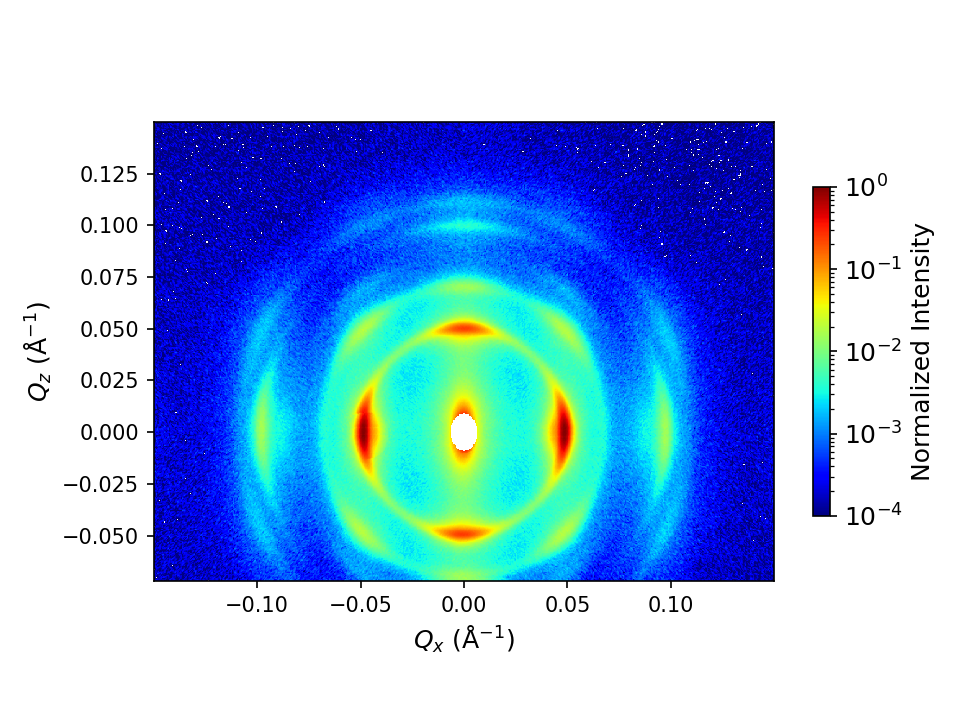

In [3]:
# compute average intensity
total_int = []
for file in filelist:
    print(file)
    proc = SAXSProcessor(file, mask = mask, instrument='LGC') 
    total_int.append(proc.data)

mean_int=np.mean(total_int,axis=0)
print(mean_int.shape)
# create saxs processor instance with this mean intensity
proc = SAXSProcessor(filelist[0], mask = mask, instrument='LGC') 
proc.data = mean_int
# plot to check
proc.plot2d_vsq(q_range=[0,0.15])



**Extraction du profil radial**

Text(0, 0.5, 'I')

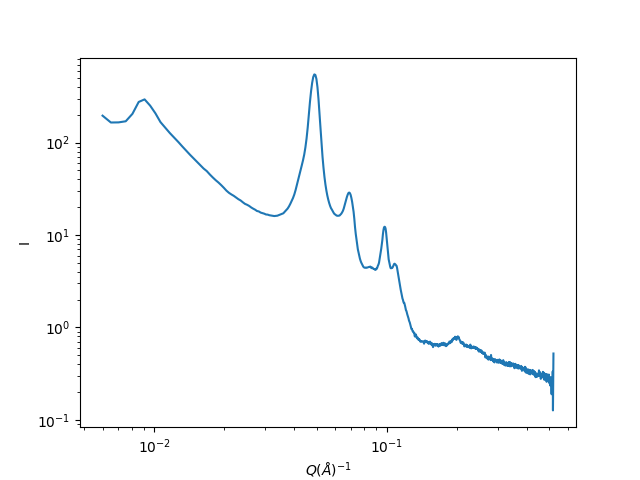

In [4]:
q,Ir = proc.extract_radial_profile(width=360)

plt.figure()
plt.loglog(q,Ir)
plt.xlabel('$Q (\AA)^{-1}$')
plt.ylabel('I')

**Find peaks**

Ici on utilise la méthode de la dérivée seconde implémentée dans correlationdistancecalculator.py

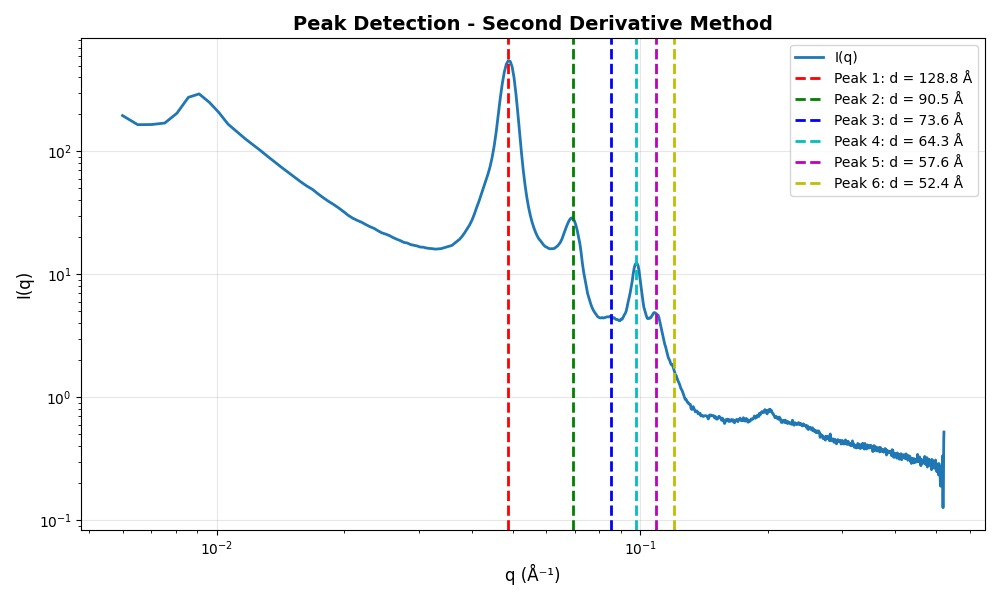

In [11]:
corr= CorrelationDistanceCalculator(proc)
peaklist = corr.detect_peaks_derivative(
    q, Ir,
    nb_peaks=6,
    window_length=15,
    polyorder=3,
    prominence=0.5,
    distance_pts=20,    
    plot=True,
    qmin = 0.03,
    qmax=0.15)

Ici il faut une séelection manuelle des pics. Ils sont tous bons sauf le premier qu'on va donc éliminer par la suite. A ce stade il faudra donc une entrée manuelle, avec suggestion automatique de la liste renvoyée par peak_detect.

Autre option, on laisse comme ça. Il suffite de ne pas exploiter le premier profil azimuthal (ne donnera rien de bien de toute façon)

**Azimuthal Profile extraction**

/home-local/ratel-ra/anaconda3_c/envs/py311/lib/python3.11/site-packages/pyFAI/azimuthalIntegrator.py:1670: RuntimeWarning: invalid value encountered in divide
  intensity = sum_signal / sum_normalization


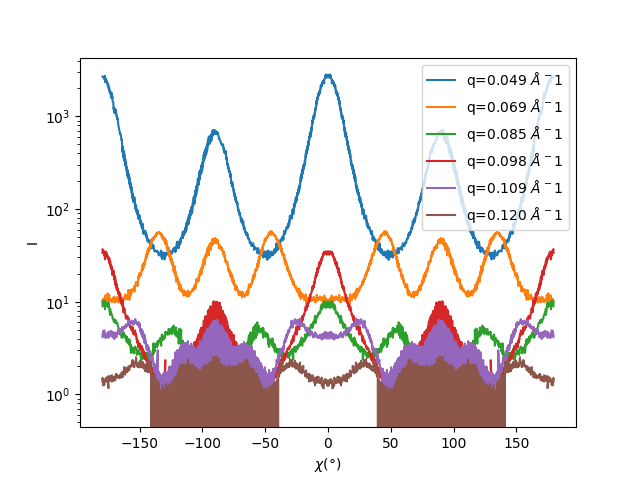

In [12]:
plt.figure()
for peak in peaklist:
    chi,I = proc.extract_azimuthal_profile(qvalue= peak, threshold= 0.05,apply_mirror=True)
    
    plt.semilogy(chi,I,label=f'q={peak:.3f} $\AA^{-1}$')
    plt.xlabel('$\\chi(°)$')
    plt.ylabel('I')
plt.legend(loc=1)

✅ SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/saxs_images/TDFeNp34_non_lavee_H400mT_Img_20_with_q-circles.png


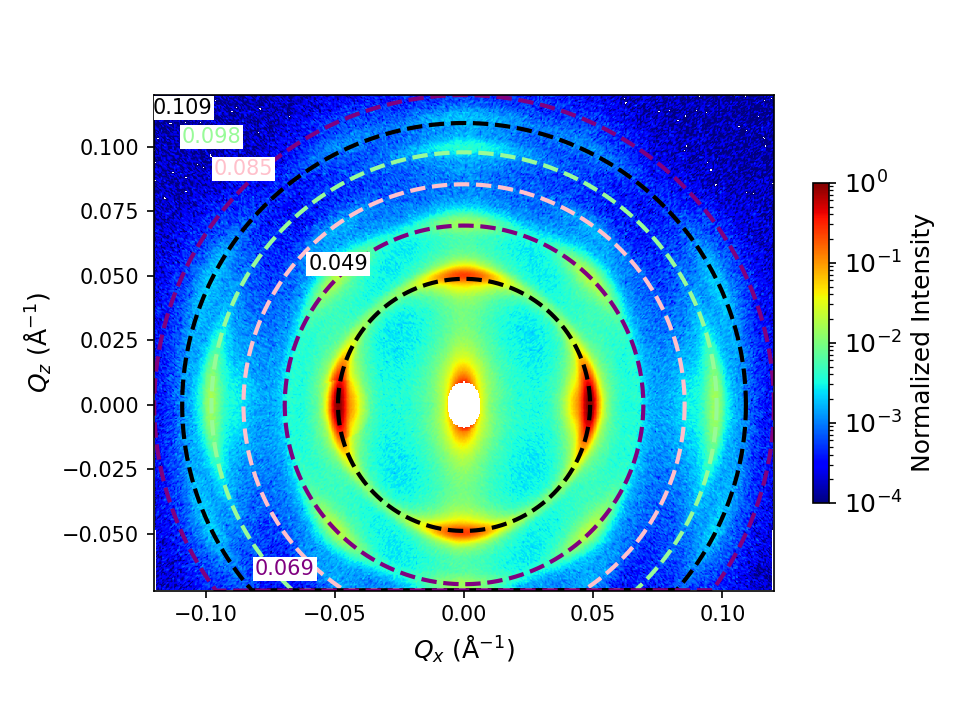

In [13]:
proc.plot2d_vsq(q_range=[0,0.12],q_circles=peaklist)